In [1]:
# Importing necessary libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
# Loading the dataset.
df = pd.read_csv("used_car_dataset.csv")

# Getting an overview of the dataset
df

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"
...,...,...,...,...,...,...,...,...,...,...,...
9577,Skoda,Octavia,2014,10,"105,904 km",Automatic,second,Diesel,Oct-24,"Skoda Octavia 1.9 Elegance TDI, 2014, Diesel","₹ 10,40,000"
9578,Maruti Suzuki,Alto-800,2020,4,"55,000 km",Manual,first,Hybrid/CNG,Nov-24,"Maruti Suzuki Alto 800 CNG LXI Optional, 2020,...","₹ 3,75,000"
9579,Maruti Suzuki,Ritz,2013,11,"92,000 km",Manual,first,Diesel,Nov-24,"Maruti Suzuki Ritz VDi, 2013, Diesel","₹ 4,15,000"
9580,Hyundai,Verna,2019,5,"72,000 km",Automatic,first,Petrol,Oct-24,"Hyundai Verna VTVT 1.6 AT SX Option, 2019, Petrol","₹ 8,55,000"


## Data Inspection

In [3]:
# Getting information about the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Brand         9582 non-null   object
 1   model         9582 non-null   object
 2   Year          9582 non-null   int64 
 3   Age           9582 non-null   int64 
 4   kmDriven      9535 non-null   object
 5   Transmission  9582 non-null   object
 6   Owner         9582 non-null   object
 7   FuelType      9582 non-null   object
 8   PostedDate    9582 non-null   object
 9   AdditionInfo  9582 non-null   object
 10  AskPrice      9582 non-null   object
dtypes: int64(2), object(9)
memory usage: 823.6+ KB


## Insights of the dataset.
- The dataset contains 9582 rows and 11 columns.
- There are missing values in the "kmdriven" column, with 47 missing entries.
- The dataser has mixed data types, with some columns being numerical and others being of object type.

In [4]:
# Getting statistical summary of the dataset.
df.describe()

,Year,Age
count,9582.000000,9582.000000
mean,2016.361094,7.638906
std,4.087226,4.087226
min,1986.000000,0.000000
25%,2014.000000,5.000000
50%,2017.000000,7.000000
75%,2019.000000,10.000000
max,2024.000000,38.000000


## Statistical insights of the dataset.
- The average age of the cars is 7.6yrs.
- The max age of the cars is 38yrs. This is likely an outlier and should be investigated further.
- Mean year of the used cars is around 2016.

# Data Cleaning

In [5]:
# Checking for duplicates.
df.duplicated().sum()

np.int64(724)

- There are 724 duplicates in the dataset. This should be investigated further to understand why there are duplicates and whether they should be removed or not.

In [6]:
# Getting a dataframe with duplicates only.
df[df.duplicated( )].head(15)

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
146,Audi,A3,2015,9,"42,000 km",Automatic,second,Diesel,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
152,Honda,City,2016,8,"93,000 km",Automatic,second,Petrol,Nov-24,Honda City 2016 Petrol Good Condition,"₹ 5,75,000"
199,Audi,A3,2015,9,"42,000 km",Automatic,second,Diesel,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"
221,Toyota,Camry,2015,9,"68,000 km",Automatic,second,Petrol,Nov-24,"Toyota Camry 2012-2014 Hybrid, 2015, Petrol","₹ 11,85,000"
230,Mercedes-Benz,GLE COUPE,2021,3,"32,000 km",Automatic,second,Petrol,Oct-24,Mercedes-Benz GLE COUPE 3.0 53 AMG 4MATIC Plus...,"₹ 1,18,00,000"
261,BMW,3 Series GT,2015,9,"61,000 km",Automatic,second,Diesel,Nov-24,"BMW 3 Series GT 320d Luxury Line, 2015, Diesel","₹ 15,00,000"
321,BMW,5 Series,2016,8,"47,000 km",Automatic,second,Diesel,Nov-24,"BMW 5 Series 3.0 530D M Sport, 2016, Diesel","₹ 25,00,000"
348,BMW,3 Series GT,2015,9,"61,000 km",Automatic,second,Diesel,Nov-24,"BMW 3 Series GT 320d Luxury Line, 2015, Diesel","₹ 15,00,000"
354,Volkswagen,Polo,2015,9,"65,000 km",Manual,first,Petrol,Nov-24,"Volkswagen Polo 1.2 MPI Comfortline, 2015, Petrol","₹ 3,75,000"
378,Audi,A3,2015,9,"42,000 km",Automatic,second,Diesel,Nov-24,"Audi A3 2.0 35 TDI Attraction, 2015, Diesel","₹ 10,50,000"


- From the dataframe with duplicates only, it can be observed that there are many duplicates of the same car. This could be due to multiple listings of the same car or errors in data collection. Further investigation is needed to determine the cause of the duplicates and whether the cars are actually the same or not.

- For now the duplocates will remain.

In [7]:
# Making all column names lowercase for consistency.
df.columns = df.columns.str.lower()


In [8]:
# Checking for missing values
df.isna().sum()

# Dropping the rows with missing values in the "kmDriven" column.
df = df.dropna(subset=["kmdriven"]).copy()


In [9]:
df.head(1)

,brand,model,year,age,kmdriven,transmission,owner,fueltype,posteddate,additioninfo,askprice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"


In [10]:
df["kmdriven"].unique()[:30]

array(['98,000 km', '190000.0 km', '77,246 km', '83,500 km', '45,000 km',
       '83,000 km', '168,000 km', '25,000 km', '33,759 km', '69,713 km',
       '70,000 km', '72,700 km', '121,931 km', '32,000 km', '130,000 km',
       '68,000 km', '65,000 km', '59,000 km', '61,000 km', '77,000 km',
       '107,000 km', '99000.0 km', '42,000 km', '48,073 km', '32,618 km',
       '51,000 km', '137,000 km', '1,996 km', '90,000 km', '84,000 km'],
      dtype=object)

In [11]:
def clean_columns(df, column, signs=[",", "km", ".", "₹"]):
    column_cleaned = df[column].astype(str) # Ensure the column is treated as string for replacement
    for sign in signs:
        column_cleaned = column_cleaned.str.replace(sign, '', regex= False)
    column_cleaned = column_cleaned.str.strip()  # Remove any leading or trailing whitespace
    return pd.to_numeric(column_cleaned, errors='coerce') # Convert to numeric, coercing errors to NaN
# Cleaning the "kmDriven" column
df["kmdriven"] = clean_columns(df, "kmdriven", signs=[",", "km", "."])
# Cleaning the "askPrice" column
df["askprice"] = clean_columns(df, "askprice", signs=[",", "₹", "."])

In [12]:
df["kmdriven"].unique()[:30]

array([  98000, 1900000,   77246,   83500,   45000,   83000,  168000,
         25000,   33759,   69713,   70000,   72700,  121931,   32000,
        130000,   68000,   65000,   59000,   61000,   77000,  107000,
        990000,   42000,   48073,   32618,   51000,  137000,    1996,
         90000,   84000])

In [13]:
df["askprice"].unique()[:30]

array([  195000,   375000,   184999,   565000,   685000,  1350000,
        1025000,  5950000,   622000,   649000,   395000,  2900000,
         240000,   201350, 11800000,   330000,  1045000,   785000,
         555000,  1500000,  2399000,  1325000,   295000,  1050000,
         355000,  1250000,   315000,   345000,   845000,  4195000])

In [14]:
df.isna().sum()

brand           0
model           0
year            0
age             0
kmdriven        0
transmission    0
owner           0
fueltype        0
posteddate      0
additioninfo    0
askprice        0
dtype: int64

In [15]:
# Changing some column data types to categorical for better memory usage and performance.
#categorical_cols = ["brand", "transmission", "owner", "fueltype"]

# Automatically find categorical columns instead of typing them manually:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Then remove columns you DON'T want to convert (like 'model', 'additioninfo')
categorical_cols = [col for col in categorical_cols if col not in ['model', 'posteddate', 'additioninfo']]

for col in categorical_cols:
    df[col] = df[col].astype('category').copy()

In [16]:
def statistics(df, column):
    print(f"These are the statistics of the {column} column:")
    print(f"Mean: {df[column].mean()}")
    print(f"Median: {df[column].median()}")
    print(f"Mode: {df[column].mode()[0]}")
    print(f"Max: {df[column].max()}")
    print(f"Min: {df[column].min()}")
    print(f"Standard Deviation: {df[column].std()}")
    print("-" * 50)
    print("\n")

In [17]:
statistics(df, "askprice")
statistics(df, "kmdriven")
statistics(df, "year")
statistics(df, "age")

These are the statistics of the askprice column:
Mean: 1067161.451074987
Median: 599999.0
Mode: 450000
Max: 42500000
Min: 15000
Standard Deviation: 1661675.3486910665
--------------------------------------------------


These are the statistics of the kmdriven column:
Mean: 119874.68631358154
Median: 69000.0
Mode: 65000
Max: 8000000
Min: 0
Standard Deviation: 229573.22533458538
--------------------------------------------------


These are the statistics of the year column:
Mean: 2016.3756685894075
Median: 2017.0
Mode: 2017
Max: 2024
Min: 1986
Standard Deviation: 4.07108994611445
--------------------------------------------------


These are the statistics of the age column:
Mean: 7.6243314105925535
Median: 7.0
Mode: 7
Max: 38
Min: 0
Standard Deviation: 4.07108994611445
--------------------------------------------------




## Visualization of the dataset.

Text(0, 0.5, 'Count')

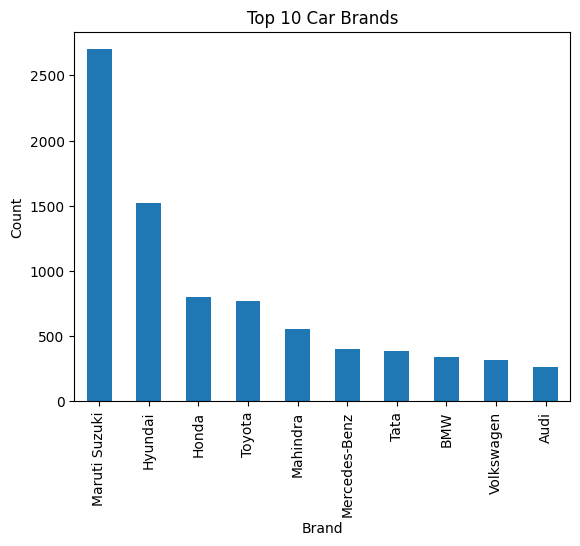

In [18]:
# Visualizing the distribution of car brands.
df["brand"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Car Brands")
plt.xlabel("Brand")
plt.ylabel("Count")


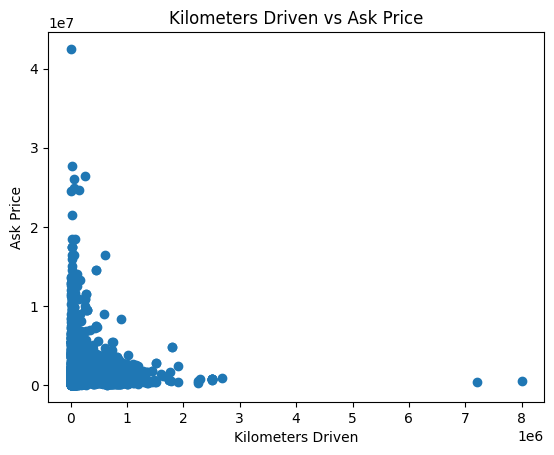

In [19]:
# Visualizing the relationship between kilometers driven and ask price.
plt.scatter(df["kmdriven"], df["askprice"])
plt.title("Kilometers Driven vs Ask Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Ask Price")
plt.show()

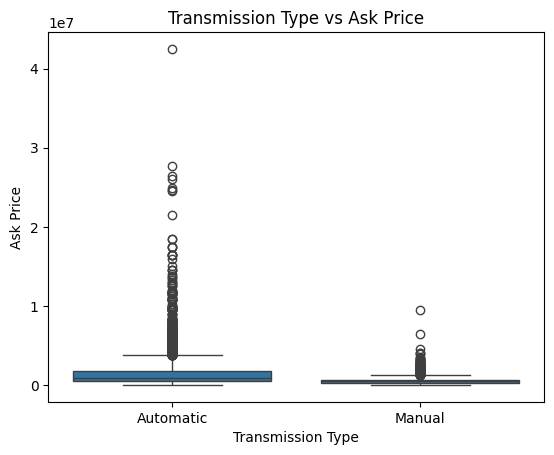

In [20]:
# Visualizating the relationship between transmission type and ask price.
sns.boxplot(x="transmission", y="askprice", data=df)
plt.title("Transmission Type vs Ask Price")
plt.xlabel("Transmission Type")
plt.ylabel("Ask Price")
plt.show()

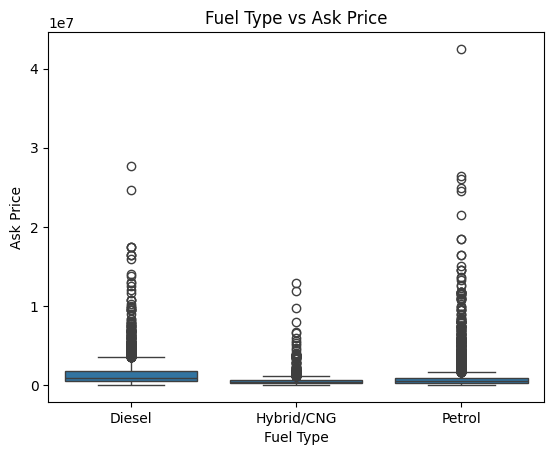

In [21]:
# Visualizating the relationship between fuel type and ask price.
sns.boxplot(x="fueltype", y="askprice", data=df)
plt.title("Fuel Type vs Ask Price")
plt.xlabel("Fuel Type")
plt.ylabel("Ask Price")
plt.show()

# Insigts from the visualizations.
- The top 10 car brands in the dataset are Maruti, Hyundai, Honda, Toyota, Ford, Mahindra, Tata, Volkswagen, Renault and Skoda.
- There is a negative correlation between kilometers driven and ask price, which is expected as cars with higher mileage tend to have lower prices.
- Cars with automatic transmission tend to have higher ask prices compared to those with manual transmission.
- Cars with petrol fuel type tend to have higher ask prices compared to those with diesel fuel type.
